## Case Study: Analysis of Health-Related Factors and Their Impact on Medical Insurance Costs

In [ ]:
# upgrade to the latest version of XGboost
!pip install --upgrade xgboost

In [1]:
# import modules and libraries
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

#### Data Preprocessing - One Hot Encoding Categorical Variables

In [2]:
# Load data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data-files/insurance_costs_dataset.csv', sep =',')

In [3]:
# Applying one-hot encoding
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.90,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.77,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.00,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.71,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.88,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.97,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.92,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.85,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.80,0,2007.94500,1,0,1,0,0,0,0,1


#### Splitting the data for training and testing

In [4]:
# Factors (X) and target variable - charges (y)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Split the data into training and testing sets (train set =80%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

#### Model Training and Comparison

In [9]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'XGBoost' :XGBRegressor()
}

# Train models and store predictions for train and test datasets
predictions_train ={}
predictions_test = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions_train[model_name] = model.predict(X_train)
    predictions_test[model_name] = model.predict(X_test)

In [11]:
# Evaluate models using Root Mean Squared Error (RMSE)
rmse_train = {}

for model_name, preds in predictions_train.items():
    rmse = root_mean_squared_error(y_train, preds)
    rmse_train[model_name] = round(rmse,4)
    # print(f'{model_name} - Root Mean Squared Error (Training): {rmse}')

In [12]:
rmse_test = {}

for model_name, preds in predictions_test.items():
    rmse = root_mean_squared_error(y_test, preds)
    rmse_test[model_name] = round(rmse,4)
    # print(f'{model_name} - Root Mean Squared Error (Testing): {rmse}')

In [13]:
# Evaluate models using R^2
r2_train = {}
for model_name, preds in predictions_train.items():
    r2 = r2_score(y_train, preds)
    r2_train[model_name] = round(r2,4)*100
    # print(f'{model_name} - R Squared (Training): {r2}')

In [14]:
# Evaluate models using R^2
r2_test = {}
for model_name, preds in predictions_test.items():
    r2 = r2_score(y_test, preds)
    r2_test[model_name] = round(r2,4)*100
    # print(f'{model_name} - R Squared (Testing): {r2}')

In [15]:
df_merged = pd.concat([pd.DataFrame([rmse_train]).T, pd.DataFrame([rmse_test]).T, pd.DataFrame([r2_train]).T, pd.DataFrame([r2_test]).T],axis=1, join='inner')
df_merged = df_merged.set_axis(["RMSE (Train)", "RMSE (Test)", "R\u00b2 (Train)", "R\u00b2 (Test)"], axis=1)
df_merged

,RMSE (Train),RMSE (Test),R² (Train),R² (Test)
Linear Regression,6105.5510,5796.3207,74.17,78.36
Ridge Regression,6105.6127,5798.3071,74.17,78.34
Lasso Regression,6105.5534,5797.0984,74.17,78.35
Random Forest,1935.7266,4652.1147,97.40,86.06
Gradient Boosting,3804.2402,4321.6749,89.97,87.97
XGBoost,850.6283,4761.0498,99.50,85.40


#### Hyperparameter Tuning for Gradient Boosting

In [97]:
# Set parameters
params = {
    "n_estimators": 300,
    "max_depth": 3,
    "min_samples_split": 2,
    "learning_rate": 0.1,
    "loss": "squared_error",
}

#Fit the model
gb1 = GradientBoostingRegressor(**params)
gb1.fit(X_train, y_train)

gb_rmse = root_mean_squared_error(y_test, gb1.predict(X_test))
gb_r2 = r2_score(y_test, gb.predict(X_test))
print("The root mean squared error (RMSE) on test set: {:.4f}".format(gb_rmse))
print("The R\u00b2 on test set: {:.4f}".format(gb_r2))

The root mean squared error (RMSE) on test set: 4513.5467
The R² on test set: 0.8571


In [66]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

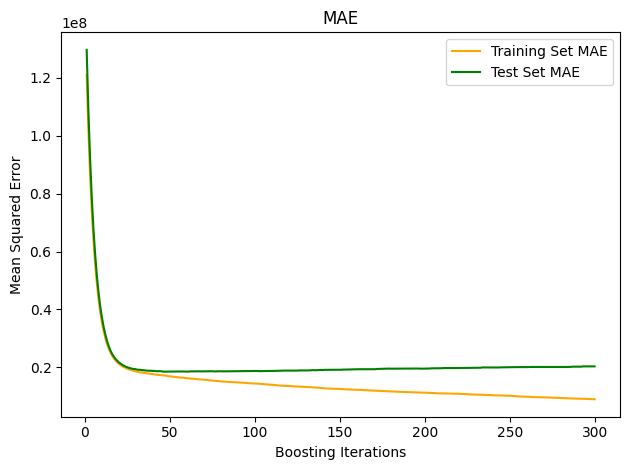

In [99]:
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(gb1.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure()
plt.subplot(1, 1, 1)
plt.title("MAE")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    gb1.train_score_,
    color="orange",
    label="Training Set MAE",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "g-", label="Test Set MAE"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Mean Squared Error")
fig.tight_layout()
plt.show()

In [101]:
# Ajust number of iterations
params2 = {
    "n_estimators": 61,
    "max_depth": 3,
    "min_samples_split": 2,
    "learning_rate": 0.1,
    "loss": "squared_error",
}

#Fit the model
gb2 = GradientBoostingRegressor(**params)
gb2.fit(X_train, y_train)
gb2_preds = gb2.predict(X_test)

gb2_rmse = root_mean_squared_error(y_test, gb2_preds)
gb2_r2 = r2_score(y_test, gb2.predict(X_test))
print("The root mean squared error (RMSE) on test set: {:.2f}".format(gb2_rmse))
print("The R\u00b2 on test set: {:.2f}".format(gb2_r2*100))

The root mean squared error (RMSE) on test set: 4309.44
The R² on test set: 88.04


#### Plot Feature Importance

In [67]:
from sklearn.inspection import permutation_importance

In [102]:
feature_names = X_test.columns
feature_names

Index(['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no',
       'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

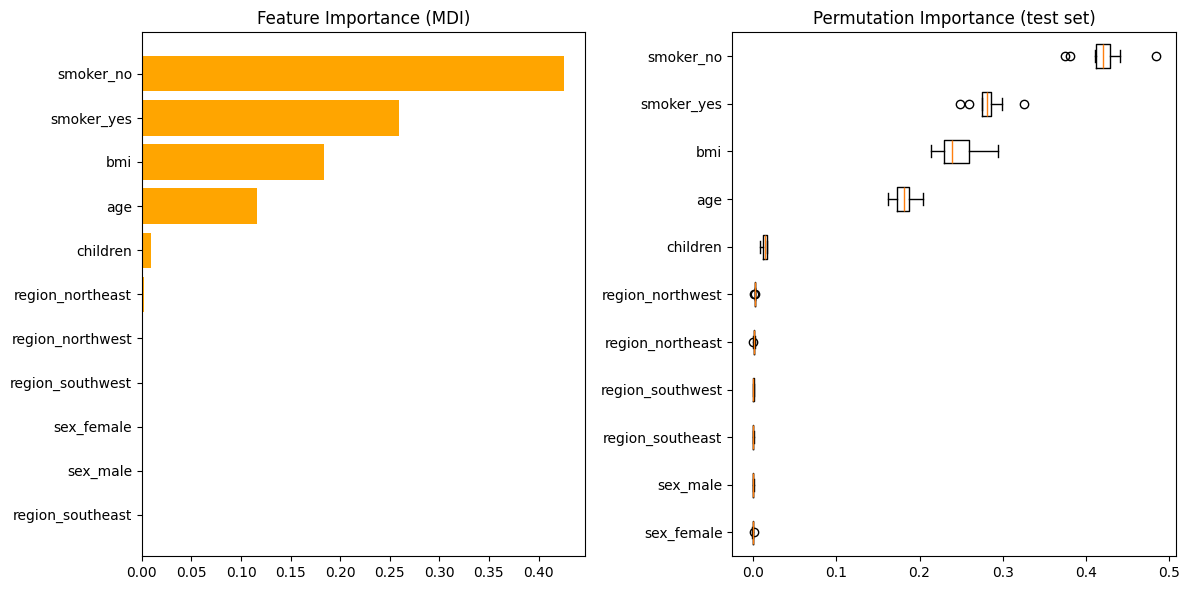

In [104]:
feature_importance = gb2.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center", color="orange")
plt.yticks(pos, np.array(feature_names[sorted_idx]))
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    gb2, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)

tick_labels_parameter_name = ("tick_labels")
tick_labels_dict = {
    tick_labels_parameter_name: np.array(feature_names[sorted_idx])
}
plt.boxplot(result.importances[sorted_idx].T, vert=False, **tick_labels_dict)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

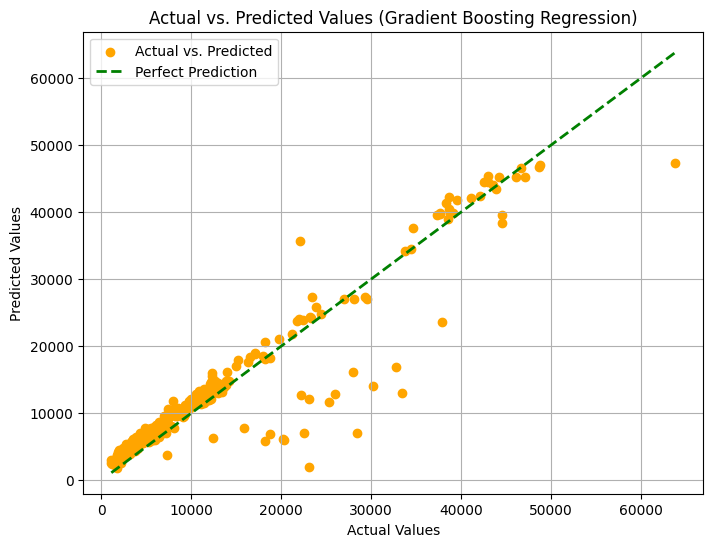

In [105]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, gb2_preds, color='orange', marker='o', label='Actual vs. Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='green', linestyle='--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (Gradient Boosting Regression)')
plt.legend()
plt.grid(True)
plt.show()